---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Основи радіоелектроніки. Частина 1"</h2></b></p>
<p style="text-align: center;"><b><h3>Тема 6. Символічний метод розрахунку кіл синусоїдного струму</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Питання теми:</b></p>
<ul style="text-align: left;">
  <li>Символічний метод розрахунку кіл синусоїдного струму</li>
  <li>Числовий приклад</li>
  <li>Векторна діаграма</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Тема 6 з 16</p>
</div>
    </th>
  </tr>
</table>

---


---

<p style="text-align: center;"><b>Зміст</b></p>

* [Символічний метод розрахунку кіл синусоїдного струму](#symbolic-ac)
    * [Числовий приклад](#symbolic-ac-example)
    * [Векторна діаграма](#phasor-diagram)
    * [🔬 Інтерактивно: векторна діаграма послідовного RLC-кола](#phasor-interactive)
    * [🔬 Інтерактивно: АЧХ і ФЧХ послідовного RLC ланцюга](#bode-rlc)
* [📌 Підсумок теми](#topic-summary)
* [📚 Рекомендована література та ресурси](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*.

---

**Підключення бібліотек.** SymPy — символьні обчислення, NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice — моделювання схем, schemdraw — побудова схем. Тут же задано стиль графіків та умовні позначення елементів за ДСТУ. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import sympy as smp
from sympy import *
from sympy import symbols, Matrix
from sympy.plotting.plot import MatplotlibBackend, Plot
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import math
from engineering_notation import EngNumber

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник,
    # джерело ЕРС — коло зі стрілкою (напрямок дії ЕРС), джерело струму — коло з подвійною стрілкою
    from schemdraw.segments import Segment
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

---

## Символічний метод розрахунку кіл синусоїдного струму <a class="anchor" id="symbolic-ac"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Представляти синусоїдні сигнали у комплексній (фазорній) формі
> - Розраховувати комплексні імпеданси елементів: $R$, $L$, $C$
> - Застосовувати методи постійного струму до кіл змінного струму через комплексні числа
> - Знаходити амплітуду та фазу напруги і струму

</div>

### Комплексні імпеданси елементів

| Елемент | Позначення | Імпеданс $Z$ | Фізична роль |
|---------|-----------|-------------|-------------|
| Резистор | $R$ | $Z_R = R$ | Активний опір, дисипація енергії |
| Котушка індуктивності | $L$ | $Z_L = j\omega L$ | Реактивний опір, накопичення енергії в полі |
| Конденсатор | $C$ | $Z_C = \cfrac{1}{j\omega C}$ | Реактивний опір, накопичення заряду |

де $\omega = 2\pi f$ — кутова частота, $j = \sqrt{-1}$ — уявна одиниця.

### Перехід від часової до частотної області

Синусоїдний сигнал $u(t) = U_m \cos(\omega t + \varphi)$ відповідає комплексній амплітуді:
$$\dot{U} = U_m e^{j\varphi} = U_m(\cos\varphi + j\sin\varphi)$$



### Числовий приклад <a class="anchor" id="symbolic-ac-example"></a>

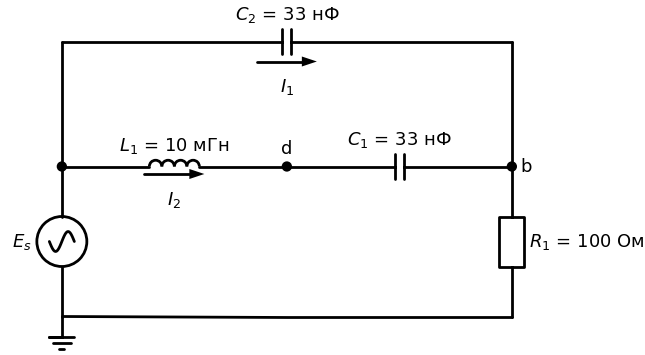

In [2]:
# Схема: коло синусоїдного струму для символічного методу (b, d — вузли, для яких обчислюються V_b, V_d)
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=13, unit=3) as d:
        Es = d.add(elm.SourceSin().up().label('$E_s$'))
        n = d.add(elm.Dot())
        d.add(elm.Line().up(2.5))
        C2 = d.add(elm.Capacitor().right(9).label('$C_2$ = 33 нФ'))
        d.add(elm.CurrentLabel(top=False, length=1.2).at(C2).label('$I_1$'))
        d.add(elm.Line().down(2.5))
        L1 = d.add(elm.Inductor().at(n.center).right(4.5).label('$L_1$ = 10 мГн'))
        d.add(elm.CurrentLabel(top=False, length=1.2).at(L1).label('$I_2$'))
        d.add(elm.Dot().label('d', loc='top'))
        d.add(elm.Capacitor().right(4.5).label('$C_1$ = 33 нФ'))
        b = d.add(elm.Dot().label('b', loc='right'))
        d.add(elm.Resistor().down().label('$R_1$ = 100 Ом', loc='bottom'))
        d.add(elm.Line().left().tox(Es.start))
        d.add(elm.Ground().at(Es.start))

Задамо параметри кола ($E_s = 1$ В, $R_1 = 100$ Ом, $L_1 = 10$ мГн, $C_1 = C_2 = 33$ нФ, $f = 2002{,}5$ Гц) і запишемо рівняння методу контурних струмів у комплексній формі: $I_1$ — струм верхньої гілки ($C_2$), $I_2$ — середньої ($L_1$, $C_1$). SymPy розв'язує систему відносно $I_1$ та $I_2$.

In [3]:
# Крок 1: параметри кола
Es_s = 1;

R1_s = 100;
L1_s = 10e-3;
C1_s = 33e-9;
C2_s = 33e-9;

f_s = 2002.5;

Es = smp.symbols('E_{s}')
R1 = smp.symbols('R_{1}')
L1 = smp.symbols('L_{1}')
C1 = smp.symbols('C_{1}')
C2 = smp.symbols('C_{2}')
W = smp.symbols('\\omega')
f = smp.symbols('f')


I1 = smp.symbols('I_{1}')
I2 = smp.symbols('I_{2}')

# Крок 2: система рівнянь
eq = [W-2*pi*f,
     -Es+I1*1/(I*W*C2) + (I1+I2)*R1,
     -Es+I2*(I*W*L1+1/(I*W*C1))+(I1+I2)*R1 ]

# Крок 3: розв'язуємо систему рівнянь
sol = smp.solve(eq, [I1, I2])
sol

{I_{1}: (C_{1}*C_{2}*E_{s}*L_{1}*\omega**3 - C_{2}*E_{s}*\omega)/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I),
 I_{2}: -C_{1}*E_{s}*\omega/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I)}

Перше рівняння системи лише пов'язує кутову частоту з частотою: $\omega = 2\pi f$.

In [4]:
eq[0]

\omega - 2*pi*f

Рівняння яке описує перший контур

In [5]:
eq[1]

-E_{s} + R_{1}*(I_{1} + I_{2}) - I*I_{1}/(C_{2}*\omega)

Рівняння яке описує другий контур

In [6]:
eq[2]

-E_{s} + I_{2}*(I*L_{1}*\omega - I/(C_{1}*\omega)) + R_{1}*(I_{1} + I_{2})

Струм в верхній гілці

In [7]:
sol[I1]

(C_{1}*C_{2}*E_{s}*L_{1}*\omega**3 - C_{2}*E_{s}*\omega)/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I)

Струм в середній гілці

In [8]:
sol[I2]

-C_{1}*E_{s}*\omega/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I)

Отримане значення струму в точках:

In [9]:
V_b = (sol[I1]+sol[I2]) * R1
V_d = (sol[I1]+sol[I2]) * R1 + sol[I2]*(1/(I*W*C1))

Комплексна напруга у вузлі $b$ (на резисторі $R_1$):

In [10]:
V_b

R_{1}*(-C_{1}*E_{s}*\omega/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I) + (C_{1}*C_{2}*E_{s}*L_{1}*\omega**3 - C_{2}*E_{s}*\omega)/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I))

Комплексна напруга у вузлі $d$ (між $L_1$ і $C_1$):

In [11]:
V_d

I*E_{s}/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I) + R_{1}*(-C_{1}*E_{s}*\omega/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I) + (C_{1}*C_{2}*E_{s}*L_{1}*\omega**3 - C_{2}*E_{s}*\omega)/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I))

Визначаємо функцію для чисельного розрахунку

In [12]:
V_b_f = lambdify([Es, R1, L1, C1, C2, W], V_b, 'numpy')
V_d_f = lambdify([Es, R1, L1, C1, C2, W], V_d, 'numpy')

Рахуємо амплітуду

In [13]:
print(np.abs(V_b_f(Es_s, R1_s, L1_s, C1_s, C2_s, 2*np.pi*f_s)))
print(np.abs(V_d_f(Es_s, R1_s, L1_s, C1_s, C2_s, 2*np.pi*f_s)))

0.08502144059651957
1.0547334056216973


Рахуємо фазу

In [14]:
print(np.angle(V_b_f(Es_s, R1_s, L1_s, C1_s, C2_s, 2*np.pi*f_s),deg=True))
print(np.angle(V_d_f(Es_s, R1_s, L1_s, C1_s, C2_s, 2*np.pi*f_s),deg=True))

85.1227422115753
-0.2536621307778553


---

Спростимо отримані вирази для контурних струмів:

In [15]:
smp.simplify(sol)

{I_{1}: (C_{1}*C_{2}*E_{s}*L_{1}*\omega**3 - C_{2}*E_{s}*\omega)/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I), I_{2}: -C_{1}*E_{s}*\omega/(C_{1}*C_{2}*L_{1}*R_{1}*\omega**3 - I*C_{1}*L_{1}*\omega**2 - C_{1}*R_{1}*\omega - C_{2}*R_{1}*\omega + I)}

Реалізуємо у  вигляді функції

In [16]:
I_function = lambdify([Es, R1, L1, C1, C2, W], sol[I1], 'numpy')

Струм

In [17]:
np.abs(I_function(Es_s, R1_s, L1_s, C1_s, C2_s, 2*np.pi*f_s))

np.float64(0.0004137051733769559)

Фаза

In [18]:
np.angle(I_function(Es_s, R1_s, L1_s, C1_s, C2_s, 2*np.pi*f_s),deg=True)

np.float64(85.1227422115753)

Як змінюється амплітуда струму $I_1$ при зміні індуктивності $L_1$ (частота та інші параметри незмінні)?

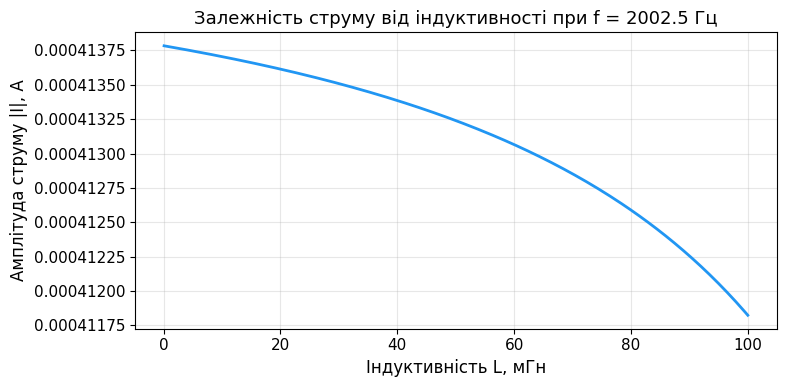

In [19]:
# Вплив значення індуктивності L на струм у послідовному RLC ланцюзі
L_values = np.linspace(0.0001, 0.1, 200)
Current = np.array([np.abs(I_function(Es_s, R1_s, L_sub, C1_s, C2_s, 2*np.pi*f_s)) for L_sub in L_values])

plt.figure(figsize=(8, 4))
plt.plot(L_values * 1000, Current, '#2196F3', linewidth=2)
plt.xlabel('Індуктивність L, мГн')
plt.ylabel('Амплітуда струму |I|, А')
plt.title('Залежність струму від індуктивності при f = %.1f Гц' % f_s)
plt.tight_layout()
plt.show()

---
### Векторна діаграма <a class="anchor" id="phasor-diagram"></a>

Комплексну амплітуду можна зобразити **вектором** на комплексній площині: довжина вектора — амплітуда (або діюче значення), кут з дійсною віссю — початкова фаза. Сукупність векторів напруг і струмів кола, побудованих з дотриманням їхніх фазових співвідношень, називають **векторною діаграмою**. Закони Кірхгофа в комплексній формі на діаграмі означають, що вектори утворюють **замкнені многокутники**.

Для послідовного $RLC$-кола струм $\dot I$ спільний для всіх елементів, тому його зручно взяти за **опорний** вектор (уздовж дійсної осі). Тоді:

- $\dot U_R = R\dot I$ — збігається за фазою зі струмом;
- $\dot U_L = j\omega L\,\dot I$ — **випереджає** струм на $90°$;
- $\dot U_C = \dfrac{1}{j\omega C}\dot I$ — **відстає** від струму на $90°$;
- вхідна напруга $\dot U = \dot U_R + \dot U_L + \dot U_C$ — замикаюча сторона многокутника.

Кут $\varphi$ між $\dot U$ і $\dot I$ — це аргумент вхідного опору: при $X_L > X_C$ ($\varphi > 0$) коло має **індуктивний** характер, при $X_L < X_C$ ($\varphi < 0$) — **ємнісний**, при $X_L = X_C$ вектори $\dot U_L$ і $\dot U_C$ компенсуються, $\varphi = 0$ — **резонанс напруг** (див. тему 7).

### 🔬 Інтерактивно: векторна діаграма послідовного RLC-кола <a class="anchor" id="phasor-interactive"></a>

Коло живиться від джерела з діючою напругою 10 В. Змінюйте частоту та параметри елементів і спостерігайте, як змінюються довжини векторів, кут $\varphi$ і характер кола. Вектор струму показано в умовному масштабі.

In [20]:
# Інтерактивно: векторна діаграма напруг послідовного RLC-кола
def series_rlc_phasor(f=300.0, R=100.0, L_mH=100.0, C_uF=1.0):
    U_src = 10.0                                         # діюча напруга джерела, В
    w = 2 * np.pi * f
    L, C = L_mH * 1e-3, C_uF * 1e-6
    ZL, ZC = 1j * w * L, 1 / (1j * w * C)
    Z = R + ZL + ZC
    I = U_src / Z
    rot = np.exp(-1j * np.angle(I))                      # струм — опорний вектор уздовж дійсної осі
    UR, UL, UC, U = I * R * rot, I * ZL * rot, I * ZC * rot, U_src * rot

    fig, ax = plt.subplots(figsize=(7.5, 6))
    def arrow(start, vec, color, label, dy=0.0):
        ax.annotate('', xy=((start + vec).real, (start + vec).imag),
                    xytext=(start.real, start.imag), arrowprops=dict(arrowstyle='-|>', lw=2.2, color=color))
        mid = start + vec / 2
        ax.text(mid.real, mid.imag + dy, '  ' + label, color=color, fontsize=12, va='center')
    m0 = max(abs(UR), abs(U), abs(UL), abs(UC))
    arrow(0j, UR, '#2196F3', '$\\dot U_R$', dy=-0.07 * m0)
    arrow(UR, UL, '#4CAF50', '$\\dot U_L$')
    arrow(UR + UL, UC, '#FF9800', '$\\dot U_C$')
    arrow(0j, U, '#F44336', '$\\dot U$')
    scale = 0.6 * max(abs(UR), abs(U)) / abs(I)
    ax.annotate('', xy=(abs(I) * scale, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='-|>', lw=1.5, ls='--', color='#9C27B0'))
    ax.text(abs(I) * scale, 0.05 * m0, '$\\dot I$', color='#9C27B0', fontsize=12, ha='right')

    pts = np.array([0, UR, UR + UL, UR + UL + UC, U, abs(I) * scale])
    m = max(np.abs(pts.real).max(), np.abs(pts.imag).max()) * 1.15 + 1e-9
    ax.set_xlim(-0.25 * m, m); ax.set_ylim(-m, m); ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
    ax.set_xlabel('Re, В'); ax.set_ylabel('Im, В')
    phi = np.degrees(np.angle(Z))
    kind = 'резонанс' if abs(phi) < 1 else ('індуктивний' if phi > 0 else 'ємнісний')
    ax.set_title(f'f = {f:.0f} Гц:  φ = {phi:.1f}°  ({kind} характер)')
    plt.tight_layout(); plt.show()

    f0 = 1 / (2 * np.pi * np.sqrt(L * C))
    print(f'X_L = {abs(ZL):.1f} Ом,  X_C = {abs(ZC):.1f} Ом,  |Z| = {abs(Z):.1f} Ом,  I = {abs(I)*1e3:.1f} мА')
    print(f'U_R = {abs(UR):.2f} В,  U_L = {abs(UL):.2f} В,  U_C = {abs(UC):.2f} В;  резонансна частота f0 = {f0:.0f} Гц')

interact(series_rlc_phasor,
         f=widgets.FloatSlider(min=50, max=2000, step=10, value=300, description='f (Гц)'),
         R=widgets.FloatSlider(min=10, max=500, step=10, value=100, description='R (Ом)'),
         L_mH=widgets.FloatSlider(min=10, max=500, step=10, value=100, description='L (мГн)'),
         C_uF=widgets.FloatSlider(min=0.1, max=10, step=0.1, value=1, description='C (мкФ)'));

interactive(children=(FloatSlider(value=300.0, description='f (Гц)', max=2000.0, min=50.0, step=10.0), FloatSl…

---
### 🔬 Інтерактивно: АЧХ і ФЧХ послідовного RLC ланцюга <a class="anchor" id="bode-rlc"></a>

<div style="background-color: #f5f3ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #7c3aed; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Змінюйте $R$, $L$ і $C$: резонансна частота $f_0 = 1/(2\pi\sqrt{LC})$ зсувається, а зменшення $R$ підвищує добротність — резонансна крива стає вужчою і вищою.

</div>

In [21]:
# Інтерактивна АЧХ/ФЧХ: послідовний RLC ланцюг
def bode_rlc_interactive(R=100.0, L_mH=10.0, C_nF=33.0):
    L = L_mH * 1e-3
    C = C_nF * 1e-9
    f_vals = np.logspace(2, 7, 1000)
    w_vals = 2 * np.pi * f_vals
    Z = R + 1j*w_vals*L + 1/(1j*w_vals*C)
    H = R / Z  # Напруга на R як частка від вхідної

    f_res = 1 / (2 * np.pi * np.sqrt(L*C))
    Q = (1/R) * np.sqrt(L/C)
    BW = f_res / Q

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
    ax1.semilogx(f_vals, 20*np.log10(np.abs(H)), color='#2196F3', linewidth=2)
    ax1.axvline(f_res, color='red', linestyle='--', label=f'f_res = {f_res:.1f} Гц')
    ax1.axhline(-3, color='orange', linestyle=':', label='-3 дБ рівень')
    ax1.set_ylabel('АЧХ |H(f)|, дБ')
    ax1.set_title(f'АЧХ послідовного RLC: R={R} Ом, L={L_mH} мГн, C={C_nF} нФ')
    ax1.legend(); ax1.set_ylim([-50, 5])

    ax2.semilogx(f_vals, np.degrees(np.angle(H)), color='#FF9800', linewidth=2)
    ax2.axvline(f_res, color='red', linestyle='--')
    ax2.set_xlabel('Частота, Гц')
    ax2.set_ylabel('ФЧХ arg(H(f)), градуси')
    ax2.set_title('Фазово-частотна характеристика')

    plt.tight_layout(); plt.show()
    print(f'Резонансна частота: f_0 = {f_res:.2f} Гц = {f_res/1e3:.3f} кГц')
    print(f'Добротність: Q = {Q:.2f}')
    print(f'Смуга пропускання: BW = {BW:.2f} Гц = {BW/1e3:.3f} кГц')
    print(f'Xc = {1/(2*np.pi*f_res*C):.2f} Ом  |  XL = {2*np.pi*f_res*L:.2f} Ом')

interact(bode_rlc_interactive,
         R=widgets.FloatSlider(min=10, max=2000, step=10, value=100, description='R (Ом)'),
         L_mH=widgets.FloatSlider(min=0.1, max=100, step=0.5, value=10, description='L (мГн)'),
         C_nF=widgets.FloatSlider(min=1, max=1000, step=1, value=33, description='C (нФ)'))

interactive(children=(FloatSlider(value=100.0, description='R (Ом)', max=2000.0, min=10.0, step=10.0), FloatSl…

<function __main__.bode_rlc_interactive(R=100.0, L_mH=10.0, C_nF=33.0)>

### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Не плутайте резонанс послідовного і паралельного RLC кіл.** У **послідовному** контурі резонанс — це **мінімум** повного опору ($Z=R$) і, відповідно, **максимум** струму від джерела. У **паралельному** (tank-) контурі все навпаки: резонанс — це **максимум** повного опору і **мінімум** струму від джерела (сам контур при цьому переносить великий циркулюючий струм між $L$ і $C$). Резонансна частота обчислюється однаковою формулою $\omega_0 = 1/\sqrt{LC}$ в обох випадках — плутанина виникає саме з поведінкою струму й опору.


</div>


---
### ⚡ Практичне застосування: Символічний метод (AC-аналіз)

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

**Застосування символічного методу в радіотехніці:**

| Тип схеми | Формула Z | Де застосовується |
|-----------|----------|-------------------|
| Послідовний RLC | $Z = R + j\omega L + \frac{1}{j\omega C}$ | Смуговий фільтр, резонансний контур |
| Паралельний RLC | $\frac{1}{Z} = \frac{1}{R} + \frac{1}{j\omega L} + j\omega C$ | Tank-схема в LC-генераторах |
| RC-фільтр | $H = \frac{1}{1 + j\omega RC}$ | Фільтр низьких частот, детектор огинаючої |
| RL-фільтр | $H = \frac{j\omega L}{R + j\omega L}$ | Фільтр високих частот |

**Добротність Q — ключовий параметр:**
$$Q = \frac{\omega_0 L}{R} = \frac{1}{\omega_0 C R} = \frac{1}{R}\sqrt{\frac{L}{C}}$$

- $Q$ визначає вибірковість резонансного контуру: чим більше $Q$, тим вужча смуга пропускання.
- У реальних радіоприймачах контур гетеродина має $Q = 50 \ldots 200$.

</div>

---
### ✅ Питання для самоперевірки: Символічний метод

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Що таке комплексна амплітуда і як вона пов'язана з миттєвим значенням?</summary>

> **Відповідь:** Комплексна амплітуда $\dot{U} = U_m e^{j\varphi}$ — комплексне число, що кодує амплітуду і фазу синусоїди. Миттєве значення: $u(t) = \text{Re}[\dot{U} e^{j\omega t}] = U_m \cos(\omega t + \varphi)$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Яка умова резонансу в послідовному RLC ланцюзі?</summary>

> **Відповідь:** Резонанс настає при $\omega_0 = 1/\sqrt{LC}$, коли $X_L = X_C$ і повний імпеданс $Z = R$ (чисто активний). Струм максимальний: $I_{\max} = E/R$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому при резонансі напруги на котушці та конденсаторі можуть бути в Q разів більші від напруги джерела?</summary>

> **Відповідь:** $U_L = U_C = Q \cdot E$, де $Q = \omega_0 L / R$. При $Q \gg 1$ напруги на реактивних елементах значно перевищують напругу джерела. Це явище — **резонансне підвищення напруги** — використовується в підсилювачах ВЧ.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4 (поглиблений).</b> Що таке передавальна функція H(jω) і як вона пов'язана з імпульсною характеристикою?</summary>

> **Відповідь:** $H(j\omega) = Y_{out}(j\omega) / X_{in}(j\omega)$ — відношення комплексних амплітуд виходу і входу. Пов'язана з імпульсною характеристикою $h(t)$ перетворенням Фур'є: $H(j\omega) = \mathcal{F}\{h(t)\}$.

</details>

---
### 📝 Задачі для самостійного розв'язання: Символічний метод


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Послідовне $RL$-коло: $R = 30$ Ом, $X_L = 40$ Ом, діюча напруга $U = 100$ В. Знайдіть комплексний опір, струм, кут зсуву фаз і напруги на елементах.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $\underline{Z} = 30 + j40 = 50e^{j53{,}13°}$ Ом; $I = 2$ А, струм відстає від напруги на $53{,}13°$; $U_R = 60$ В, $U_L = 80$ В ($60^2 + 80^2 = 100^2$ ✔).

</details>

<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Послідовне $RC$-коло: $R = 100$ Ом, $C = 1$ мкФ, $f = 1$ кГц, $U = 10$ В. Знайдіть $X_C$, $|\underline Z|$, $\varphi$ та струм.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $X_C = \dfrac{1}{2\pi fC} \approx 159{,}2$ Ом; $|\underline Z| = \sqrt{100^2 + 159{,}2^2} \approx 188$ Ом; $\varphi \approx -57{,}9°$ (ємнісний характер); $I \approx 53{,}2$ мА.

</details>

---

### 📌 Підсумок теми <a class="anchor" id="topic-summary"></a>

<div style="background-color: #f0fdf4; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Поняття | Формула |
|---|---|
| Комплексна амплітуда | $u(t) = U_m\cos(\omega t + \varphi) \;\leftrightarrow\; \dot U = U_m e^{j\varphi}$ |
| Диференціювання / інтегрування | $\dfrac{d}{dt} \to j\omega$, $\;\displaystyle\int dt \to \dfrac{1}{j\omega}$ |
| Імпеданси елементів | $Z_R = R$, $\;Z_L = j\omega L$, $\;Z_C = \dfrac{1}{j\omega C}$ |
| Комплексний опір | $Z = R + jX = \vert Z\vert e^{j\varphi}$, $\;X = X_L - X_C$ |
| Закон Ома | $\dot U = Z\dot I$ |
| Закони Кірхгофа | $\sum\dot I_k = 0$, $\;\sum\dot E_k = \sum Z_k\dot I_k$ |

**Алгоритм символічного методу.** (1) Замінити синусоїдні ЕРС і струми комплексними амплітудами, а елементи — імпедансами. (2) Розрахувати коло будь-яким методом постійного струму (Кірхгофа, контурних струмів, вузлових потенціалів, еквівалентного генератора) у комплексній формі. (3) Перейти від знайдених комплексних амплітуд до миттєвих значень: $\dot I = I_m e^{j\psi} \to i(t) = I_m\cos(\omega t + \psi)$.

**Головні висновки.** Символічний метод перетворює диференціальні рівняння кола на алгебраїчні. Векторна діаграма наочно показує фазові співвідношення: на індуктивності напруга випереджає струм на $90°$, на ємності — відстає на $90°$; знак кута $\varphi$ визначає характер кола.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Бойко В. С., Бойко В. В., Видолоб Ю. Ф. та ін. Теоретичні основи електротехніки: підручник. Т. 1. Усталені режими лінійних електричних кіл із зосередженими параметрами. — К.: ІВЦ «Видавництво «Політехніка», 2004.
2. Гоноровский И. С. Радиотехнические цепи и сигналы. — М.: Радио и связь, 1986.
3. Баскаков С. И. Радиотехнические цепи и сигналы. — М.: Высшая школа, 2000.
4. Alexander C. K., Sadiku M. N. O. Fundamentals of Electric Circuits. — McGraw-Hill.

**Додаткова література**

5. Oppenheim A. V., Willsky A. S. Signals and Systems. — 2nd ed. — Prentice Hall, 1997.
6. Lathi B. P., Ding Z. Modern Digital and Analog Communication Systems. — Oxford University Press.
7. Pozar D. M. Microwave Engineering. — 4th ed. — Wiley, 2012 *(розділ про лінії передачі)*.

**Програмні інструменти, що використовуються в конспекті**

- [SymPy](https://docs.sympy.org/) — символьні обчислення (розв'язання систем рівнянь, перетворення Лапласа)
- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки

---

<p style="text-align: center;">⬅️ [Тема 5. Метод еквівалентного генератора. Принцип накладення](Тема_05_Метод_еквівалентного_генератора_та_накладення.ipynb) &nbsp;|&nbsp; [Тема 7. Параметри синусоїдного струму. Потужність і резонанс](Тема_07_Потужність_та_резонанс.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*
